# Selection criteria for the HMM hits

Working notebook for deciding when an hmmsearch hit counts as an ortholog of the arabinose cluster genes.

Input: the unfiltered hmmsearch `.tblout` files from `05_search_genomes.py` (no cutoff applied, hits go down to
HMMER's default E = 10), for both genome sets:
- `results/raw/Streptomycetae/`
- `results/raw/Actinobacteria/`

### Table: `hmm_hits`

Every hit from hmmsearch, one row per (protein, HMM model), from both genome sets together (34,407 hits from 459 genomes).
No threshold is applied: hits go down to HMMER's default E = 10.

**Source:** the `.tblout` files in `results/raw/Streptomycetae/` (207 genomes) and `results/raw/Actinobacteria/` (252 genomes),
one file per genome.

**Columns:**
- `target`: the protein that was hit, as `Genome|LOCUS_TAG|description` (its .faa header up to the first space)
- `evalue`, `bitscore`: score of the whole protein against the model
- `best_dom_evalue`, `best_dom_bitscore`: score of its best single domain
- other HMMER tblout columns (`bias`, `exp`, `reg`, `clu`, `ov`, `env`, `dom`, `rep`, `inc`, `description`, ...): unchanged from the `.tblout`
- `genome_set`: `Streptomycetae` or `Actinobacteria`, the genome collection (folder) the hit comes from, not the taxonomy
- `tblout`: name of the `.tblout` / `.faa` file of the genome
- `genome`: genome name taken from `target` (brackets removed, so `[Kitasatospora]_papulosa` matches the RBH names)
- `target_locus_tag`: locus tag taken from `target`
- `query_gene`: the HMM model, without its `Conserved-` / `Conserved_` prefix (e.g. `AraD`, `SCO2401`, `lacI-AraR`)
- `rank`: rank of the hit among all hits of the same model in the same genome, by bitscore (1 = best-scoring protein)
- `is_rbh`: added in section 2: the hit is a reciprocal best hit in the **Streptomycetae** RBH run (always False for
  Actinobacteria hits)

**Note:** a genome that is in both collections appears twice, once per `genome_set`, with its own `tblout` and locus tags
(e.g. *S. coelicolor* A3(2): `Streptomyces_coelicolor_A3(2)` with `FQ762_RS…` tags in Actinobacteria,
`Streptomyces_coelicolor_A3(2)_protein` with `SCO…` tags in Streptomycetae).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
HMM_DIR = PROJECT_DIR / "hmm_search"
RAW_DIRS = {
    "Streptomycetae": HMM_DIR / "results" / "raw" / "Streptomycetae",
    "Actinobacteria": HMM_DIR / "results" / "raw" / "Actinobacteria",
}

# tblout columns (HMMER 3 --tblout); the last one, the description, can contain spaces
TBLOUT_COLS = [
    "target", "target_acc", "model", "model_acc",
    "evalue", "bitscore", "bias",
    "best_dom_evalue", "best_dom_bitscore", "best_dom_bias",
    "exp", "reg", "clu", "ov", "env", "dom", "rep", "inc",
    "description",
]
FLOAT_COLS = ["evalue", "bitscore", "bias", "best_dom_evalue", "best_dom_bitscore", "best_dom_bias", "exp"]

## Lookup table: RBH query names -> HMM model names

In [2]:
# RBH query name (reciprocal_hits.tsv qseqid = FASTA header in RBH/data/arabinose_clusters/)
# -> hmmsearch model name (as in the .tblout files), so RBH and HMM hits share one identifier
RBH_TO_MODEL = {
    "SCO2401": "SCO2401",
    "SCO2402": "SCO2402",
    "SCO2403": "SCO2403",
    "SCO2407": "SCO2407",
    "SCO2439": "SCO2439",
    "SCO2440": "SCO2440",
    "vnz_33170-lacI": "lacI-AraR",
    "vnz_33175-araB": "AraB",
    "vnz_33180-araA": "AraA",
    "vnz_33185-araD": "AraD",
}

## 1. Load the hits

In [3]:
def read_tblout(path):
    """Returns (hits table, finished): finished is False when the '# [ok]' line is missing."""
    rows = []
    finished = False
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                if line.startswith("# [ok]"):
                    finished = True
                continue
            rows.append(line.rstrip("\n").split(maxsplit=len(TBLOUT_COLS) - 1))
    return pd.DataFrame(rows, columns=TBLOUT_COLS), finished


tables = []
for genome_set, raw_dir in RAW_DIRS.items():
    for path in sorted(raw_dir.glob("*.tblout")):
        df, finished = read_tblout(path)
        if not finished:
            print("WARNING: search did not finish:", path.name)
        df["genome_set"] = genome_set
        df["tblout"] = path.stem
        tables.append(df)

hmm_hits = pd.concat(tables, ignore_index=True)
hmm_hits[FLOAT_COLS] = hmm_hits[FLOAT_COLS].astype(float)

# 'Genome|LOCUS_TAG|description|accession'; brackets dropped so '[Kitasatospora]_papulosa' matches RBH
hmm_hits["genome"] = hmm_hits.target.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
hmm_hits["target_locus_tag"] = hmm_hits.target.str.split("|").str[1]
# query gene = HMM model name without its Conserved- / Conserved_ prefix (every model has it),
# the same names as the RBH_TO_MODEL values
hmm_hits["query_gene"] = hmm_hits.model.str.replace(r"^Conserved[-_]", "", regex=True)
hmm_hits = hmm_hits.drop(columns="model")
# rank of each hit within its (genome, query gene): 1 = best-scoring protein
hmm_hits = hmm_hits.sort_values("bitscore", ascending=False)
hmm_hits["rank"] = hmm_hits.groupby(["genome_set", "genome", "query_gene"]).cumcount() + 1

print(f"{len(hmm_hits)} hits from {hmm_hits.tblout.nunique()} genomes")
hmm_hits.groupby(["genome_set", "query_gene"]).agg(genomes=("genome", "nunique"), hits=("target", "size"))

34407 hits from 459 genomes


genomes  hits
genome_set     query_gene               
Actinobacteria AraA            123   151
               AraB            245  1044
               AraD            192   398
               SCO2401         227   935
               SCO2402         248  3983
               SCO2403          73   104
               SCO2407         187   272
               SCO2439         156   387
               SCO2440         232  1951
               lacI-AraR       236  3988
Streptomycetae AraA             64    78
               AraB            207  1316
               AraD            207   623
               SCO2401         196  1115
               SCO2402         207  6318
               SCO2403         155   374
               SCO2407         199   451
               SCO2439         197   559
               SCO2440         207  3520
               lacI-AraR       207  6840

In [4]:
hmm_hits

,target,target_acc,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,exp,...,dom,rep,inc,description,genome_set,tblout,genome,target_locus_tag,query_gene,rank
19702,Streptomyces_venezuelae|vnz_RS33510|ribulokina...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_strain_NRRL_B-65442,Streptomyces_venezuelae,vnz_RS33510,AraB,1
19618,Streptomyces_venezuelae_ATCC_10712|DEJ43_RS336...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_venezuelae_ATCC_10712_protein,Streptomyces_venezuelae_ATCC_10712,DEJ43_RS33660,AraB,1
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,-,0.00,1043.9,8.7,0.000,1043.8,8.7,1.0,...,1,1,1,-,Actinobacteria,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1
18774,Streptomyces_tanashiensis|LDH80_RS06025|ribulo...,-,-,0.00,1043.2,5.2,0.000,1042.9,5.2,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_tanashiensis_protein,Streptomyces_tanashiensis,LDH80_RS06025,AraB,1
8144,Streptomyces_gardneri|H4W23_RS03215|ribulokina...,-,-,0.00,1042.9,5.6,0.000,1042.6,5.6,1.0,...,1,1,1,-,Streptomycetae,Streptomyces_gardneri_protein,Streptomyces_gardneri,H4W23_RS03215,AraB,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18638,Streptomyces_stoeckheimensis|ACE1OC_RS37635|xy...,-,-,1.60,5.9,11.1,0.150,9.3,0.2,3.1,...,4,4,0,-,Streptomycetae,Streptomyces_stoeckheimensis_protein,Streptomyces_stoeckheimensis,ACE1OC_RS37635,AraB,5
28998,Mycobacterium_tuberculosis_H37Rv|Rv2181|alpha-...,-,-,1.20,5.9,6.3,1.900,5.3,0.6,2.5,...,3,3,0,mannoside mannosyltransferase|NP_216697.1,Actinobacteria,Mycobacterium_tuberculosis_H37Rv,Mycobacterium_tuberculosis_H37Rv,Rv2181,SCO2402,14
30139,Paeniglutamicibacter_sp._Y32M11|KUF55_RS08720|...,-,-,0.74,5.8,6.8,0.068,9.3,1.6,1.7,...,2,2,0,cytochrome|WP_132363896.1,Actinobacteria,Paeniglutamicibacter_sp._Y32M11,Paeniglutamicibacter_sp._Y32M11,KUF55_RS08720,AraB,3
5426,Streptomyces_clavuligerus|CRV15_RS31785|hypoth...,-,-,3.30,5.3,7.4,3.800,5.0,6.9,1.5,...,1,1,0,protein|WP_009999291.1,Streptomycetae,Streptomyces_clavuligerus_protein,Streptomyces_clavuligerus,CRV15_RS31785,SCO2407,4


In [5]:
#RBH_HITS_NONSTRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae_nonstrict_2026-09-27" / "reciprocal" / "reciprocal_hits.tsv"
RBH_HITS_NONSTRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"

MATCH_COLS = ["genome_set", "genome", "locus_tag", "gene"]

rbh_hits = pd.read_csv(RBH_HITS_NONSTRICT, sep="\t")
rbh_hits["rbh_query"] = rbh_hits.qseqid
rbh_hits["qseqid"] = rbh_hits.qseqid.map(RBH_TO_MODEL)
unmapped = rbh_hits.loc[rbh_hits.qseqid.isna(), "rbh_query"].unique()
unmapped


array([], dtype=object)

## 2. Add the RBH hits 

## 1. For Streptomyes datataset

In [6]:
RBH_HITS_NONSTRICT = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_streptomycetae" / "reciprocal" / "reciprocal_hits.tsv"


MATCH_COLS = ["genome_set", "genome", "target_locus_tag", "query_gene"]
# reciprocal best hits, only run against the Streptomycetae genomes; SCO and VNZ queries both kept,
# mapped to their HMM model names in query_gene (original query name stays in qseqid)
rbh_hits = pd.read_csv(RBH_HITS_NONSTRICT, sep="\t")
rbh_hits["query_gene"] = rbh_hits.qseqid.map(RBH_TO_MODEL)
unmapped = rbh_hits.loc[rbh_hits.query_gene.isna(), "qseqid"].unique()
if len(unmapped):
    print("WARNING: RBH queries missing from RBH_TO_MODEL:", ", ".join(unmapped))
rbh_hits["genome_set"] = "Streptomycetae"
rbh_hits["target_locus_tag"] = rbh_hits.sseqid.str.split("|").str[1]
# drop RBH queries whose model is not in the current hmmsearch results
rbh_hits = rbh_hits[rbh_hits.query_gene.isin(hmm_hits.query_gene.unique())]

rbh_keys = pd.MultiIndex.from_frame(rbh_hits[MATCH_COLS])
hmm_keys = pd.MultiIndex.from_frame(hmm_hits[MATCH_COLS])
hmm_hits["is_rbh"] = hmm_keys.isin(rbh_keys)

# RBH hits that hmmsearch did not report at all
missed = rbh_hits[~rbh_keys.isin(hmm_keys)]
print(f"{hmm_hits.is_rbh.sum()} of {len(rbh_hits)} RBH hits found among the HMM hits")
if len(missed):
    print(missed.groupby("query_gene").size().to_string())

# rank of the RBH hits within their (genome, query gene)
hmm_hits[hmm_hits.is_rbh].groupby("query_gene")["rank"].value_counts().unstack(fill_value=0)

885 of 885 RBH hits found among the HMM hits


rank,1,2,3
query_gene,,,
AraA,32,2,1
AraB,32,3,1
AraD,24,2,1
SCO2401,130,0,0
SCO2402,130,1,0
SCO2403,129,1,0
SCO2407,95,0,0
SCO2439,125,0,0
SCO2440,132,1,0


## 2. For Actinobacteria (good to have but not used)

In [7]:
# Actinobacteria RBH run; rows without rev_bitscore failed the reciprocal check
RBH_ACTINO_HITS = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_actinos" / "reciprocal" / "reciprocal_hits.tsv"

rbh_actino = pd.read_csv(RBH_ACTINO_HITS, sep="\t")
print(f"{rbh_actino.rev_bitscore.isna().sum()} forward hits failed the reciprocal check (dropped)")
rbh_actino = rbh_actino[rbh_actino.rev_bitscore.notna()].copy()
rbh_actino["query_gene"] = rbh_actino.qseqid.map(RBH_TO_MODEL)
rbh_actino["genome_set"] = "Actinobacteria"
# brackets dropped, as for the HMM genome names ('[Actinomadura]_parvosata_subsp._kistnae')
rbh_actino["genome"] = rbh_actino.sseqid.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
rbh_actino["target_locus_tag"] = rbh_actino.sseqid.str.split("|").str[1]

# is_rbh of the Actinobacteria hits (the cell above only set the Streptomycetae hits)
rbh_actino_keys = pd.MultiIndex.from_frame(rbh_actino[MATCH_COLS])
is_actino = hmm_hits.genome_set == "Actinobacteria"
hmm_hits.loc[is_actino, "is_rbh"] = pd.MultiIndex.from_frame(hmm_hits.loc[is_actino, MATCH_COLS]).isin(rbh_actino_keys)

# RBH hits that hmmsearch did not report (e.g. genomes in the RBH database that were not HMM-searched)
missed = rbh_actino[~rbh_actino_keys.isin(pd.MultiIndex.from_frame(hmm_hits[MATCH_COLS]))]
print(f"{hmm_hits[is_actino].is_rbh.sum()} of {len(rbh_actino)} Actinobacteria RBH hits found among the HMM hits")
if len(missed):
    print(missed.groupby("genome").size().to_string())

# RBH hits per gene, both genome sets
hmm_hits.groupby(["query_gene", "genome_set"]).is_rbh.sum().unstack()

2 forward hits failed the reciprocal check (dropped)
340 of 343 Actinobacteria RBH hits found among the HMM hits
genome
Bacillus_subtilis_subsp._subtilis_str._168    3


genome_set,Actinobacteria,Streptomycetae
query_gene,,
AraA,96,35
AraB,65,36
AraD,5,27
SCO2401,8,130
SCO2402,10,131
SCO2403,15,130
SCO2407,20,95
SCO2439,26,125
SCO2440,16,133


Benchmark the RBH Streptomyces results against the HMM hits:
1. Take every RBH hit per query gene and genome (all copies kept, no top-hit selection)
2. Select the top HMM hits per model 
3. Merge the two tables resulting tables, maching on the model/query gene and genome 
4. Account that sometimes there are multiple hits in RBH in a genome (duplications)

In [9]:
# every RBH hit for every (query gene, genome); all copies kept (e.g. the three araB copies of S. canus,
# each passing the reciprocal check on its own), so a pair can have more than one row
rbh_renamed = rbh_hits.rename(columns={"target_locus_tag": "rbh_locus_tag", "sseqid": "rbh_hit", "pident": "rbh_pident",
                                       "evalue": "rbh_evalue", "bitscore": "rbh_bitscore"})

# top HMM hit for every (model, genome) in the Streptomycetae set
hmm_top = (
    hmm_hits[(hmm_hits.genome_set == "Streptomycetae") & (hmm_hits["rank"] == 1)]
    .rename(columns={"target_locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore"})
)

benchmark = rbh_renamed[["query_gene", "genome", "rbh_locus_tag", "rbh_hit", "rbh_pident", "rbh_evalue", "rbh_bitscore"]].merge(
    hmm_top[["query_gene", "genome", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "is_rbh"]],
    how="left", on=["query_gene", "genome"],
)

# 

In [10]:
rbh_renamed

,qseqid,rbh_hit,rbh_pident,length,qlen,slen,qstart,qend,sstart,send,...,rbh_bitscore,full_sseq,query_file,ref_group,true_ref_id,genome,rev_bitscore,query_gene,genome_set,rbh_locus_tag
0,SCO2401,Streptomyces_coelicolor_A3(2)|SCO2401|dehydrat...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicolor_A3(2),794.0,SCO2401,Streptomycetae,SCO2401
1,SCO2401,Streptomyces_violaceoruber|R2E43_RS26250|mande...,99.7,388,388,388,1,388,1,388,...,791,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_violaceoruber,794.0,SCO2401,Streptomycetae,R2E43_RS26250
2,SCO2401,Streptomyces_anthocyanicus|OIE72_RS26120|mande...,99.5,388,388,388,1,388,1,388,...,790,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_anthocyanicus,793.0,SCO2401,Streptomycetae,OIE72_RS26120
3,SCO2401,Streptomyces_rubrogriseus|Sru02f_RS06985|mande...,99.0,388,388,388,1,388,1,388,...,788,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_rubrogriseus,790.0,SCO2401,Streptomycetae,Sru02f_RS06985
4,SCO2401,Streptomyces_coelicoflavus|OHA99_RS25815|mande...,98.7,388,388,388,1,388,1,388,...,786,MRITGISTHVVGTPWRNLTYVQVHTDEGLTGVGETRMLGHTDALLG...,SCO2401,SCO,SCO2401,Streptomyces_coelicoflavus,787.0,SCO2401,Streptomycetae,OHA99_RS25815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,vnz_33185-araD,Streptomyces_canus|OHT68_RS00520|L-ribulose-5-...,77.5,236,237,241,1,235,1,236,...,365,MTAHVRDGLRQEVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,371.0,AraD,Streptomycetae,OHT68_RS00520
881,vnz_33185-araD,Streptomyces_cynarae|N8I84_RS40475|L-ribulose-...,77.9,235,237,240,1,234,1,235,...,363,MTTAVPESLRQEVLEANLAIPQVGLATLTWGNVSGVDRKSGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_cynarae,370.0,AraD,Streptomycetae,N8I84_RS40475
882,vnz_33185-araD,Streptomyces_canus|OHT68_RS02545|L-ribulose-5-...,77.4,235,237,241,1,234,1,235,...,362,MTTTVPESLRREVLDANLAIPQVGLATLTWGNVSGVDREAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_canus,370.0,AraD,Streptomycetae,OHT68_RS02545
883,vnz_33185-araD,Streptomyces_prunicolor|OG588_RS46515|L-ribulo...,77.6,237,237,239,1,236,1,237,...,361,MTARVRDGLRQEVLDANLTIPRVGLATLTWGNVSGVDRAAGVFVIK...,vnz_33185,VNZ,vnz_RS33520,Streptomyces_prunicolor,368.0,AraD,Streptomycetae,OG588_RS46515


In [11]:
#a genome can have more than one RBH hit per gene (paralogs, e.g. S. zaomyceticus SCO2440):
# the pair agrees when the top HMM hit is any of its RBH hits, not only the top one
agrees = benchmark.is_rbh.fillna(False).astype(bool)
# one row per pair: a pair with several RBH copies has one benchmark row per copy
agree_pairs = benchmark.loc[agrees, ["query_gene", "genome"]].drop_duplicates()

strep_hits = hmm_hits[hmm_hits.genome_set == "Streptomycetae"]

# true hits: every RBH-confirmed HMM hit of the agreeing pairs, so a pair with 2 RBH hits gives 2 rows
agreement_rbh_hmm_table = (
    strep_hits[strep_hits.is_rbh]
    .merge(agree_pairs, on=["query_gene", "genome"])
    .rename(columns={"target_locus_tag": "hmm_locus_tag", "target": "hmm_hit",
                     "evalue": "hmm_evalue", "bitscore": "hmm_bitscore", "rank": "hmm_rank"})
    [["query_gene", "genome", "hmm_locus_tag", "hmm_hit", "hmm_evalue", "hmm_bitscore", "hmm_rank"]]
    .reset_index(drop=True)
)

# second-best: the best HMM hit that is not an RBH hit (rank 2 can itself be an RBH paralog),
# with the gap measured from the lowest-scoring true hit of the pair
best_non_rbh = (
    strep_hits[~strep_hits.is_rbh]
    .sort_values("bitscore", ascending=False)
    .groupby(["query_gene", "genome"])
    .head(1)
    .rename(columns={"target_locus_tag": "second_locus_tag", "target": "second_hit",
                     "evalue": "second_evalue", "bitscore": "second_bitscore", "rank": "second_rank"})
)
lowest_true_per_pair = agreement_rbh_hmm_table.loc[
    agreement_rbh_hmm_table.groupby(["query_gene", "genome"]).hmm_bitscore.idxmin(),
    ["query_gene", "genome", "hmm_locus_tag", "hmm_bitscore"],
]
second_best_hits = lowest_true_per_pair.merge(
    best_non_rbh[["query_gene", "genome", "second_locus_tag", "second_hit", "second_evalue", "second_bitscore", "second_rank"]],
    on=["query_gene", "genome"],
).reset_index(drop=True)
second_best_hits["bitscore_gap"] = second_best_hits.hmm_bitscore - second_best_hits.second_bitscore

not_agreement_rbh_hmm_table = benchmark[~agrees].drop(columns="is_rbh").reset_index(drop=True)


not_agree_pairs = not_agreement_rbh_hmm_table[["query_gene", "genome"]].drop_duplicates()
print(f"{len(agree_pairs)} pairs agree ({len(agreement_rbh_hmm_table)} true hits), "
      f"{len(not_agree_pairs)} do not agree ({len(not_agreement_rbh_hmm_table)} RBH hits)")
print(f"{len(second_best_hits)} agreeing pairs have a non-RBH HMM hit")
pd.DataFrame({
    "agree": agree_pairs.groupby("query_gene").size(),
    "true_hits": agreement_rbh_hmm_table.groupby("query_gene").size(),
    "not_agree": not_agree_pairs.groupby("query_gene").size(),
}).fillna(0).astype(int)

872 pairs agree (885 true hits), 0 do not agree (0 RBH hits)
837 agreeing pairs have a non-RBH HMM hit


,agree,true_hits,not_agree
query_gene,,,
AraA,32,35,0
AraB,32,36,0
AraD,24,27,0
SCO2401,130,130,0
SCO2402,130,131,0
SCO2403,129,130,0
SCO2407,95,95,0
SCO2439,125,125,0
SCO2440,132,133,0


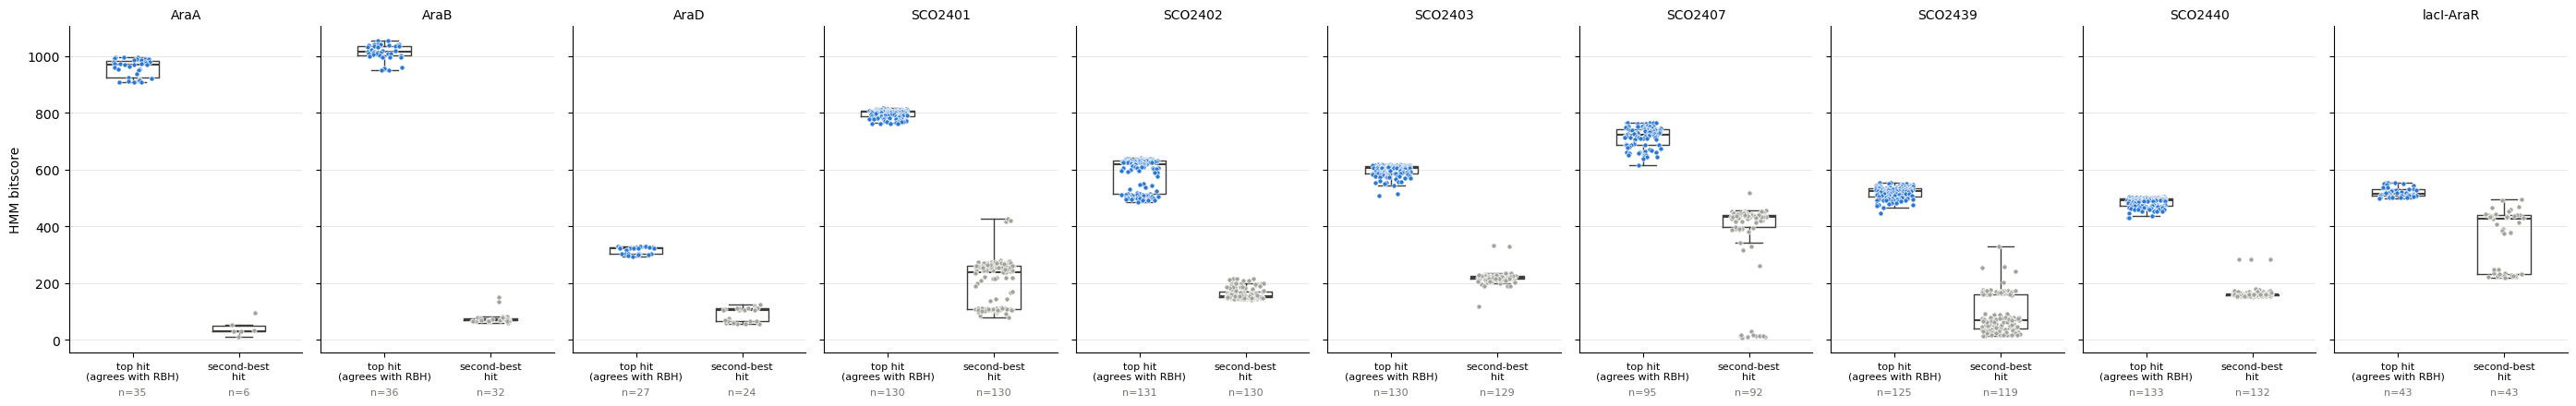

In [12]:
C_TOP = "#2a78d6"     # top HMM hit = RBH ortholog
C_SECOND = "#a3a29b"  # second-best HMM hit

genes = sorted(agreement_rbh_hmm_table.query_gene.unique())
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(genes), figsize=(2.8 * len(genes), 4.5), sharey=True)

for ax, gene in zip(axes, genes):
    groups = [
        ("top hit\n(agrees with RBH)", agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.query_gene == gene, "hmm_bitscore"], C_TOP),
        ("second-best\nhit", second_best_hits.loc[second_best_hits.query_gene == gene, "second_bitscore"], C_SECOND),
    ]
    for x, (label, values, color) in enumerate(groups):
        ax.boxplot(values, positions=[x], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        ax.scatter(x + rng.uniform(-0.18, 0.18, len(values)), values, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
        ax.text(x, -0.13, f"n={len(values)}", transform=ax.get_xaxis_transform(),
                ha="center", fontsize=8, color="#73726c")
    ax.set_xticks([0, 1], [label for label, _, _ in groups], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(gene, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("HMM bitscore")
fig.tight_layout()
plt.show()

Check what is the second best hit in the SCO2403

In [13]:
second_best_hits.loc[second_best_hits.query_gene == "SCO2403"].sort_values("bitscore_gap", ascending=True).head(10)

,query_gene,genome,hmm_locus_tag,hmm_bitscore,second_locus_tag,second_hit,second_evalue,second_bitscore,second_rank,bitscore_gap
340,SCO2403,Streptomyces_boninensis,ACNNMR_RS23280,575.1,ACNNMR_RS28385,Streptomyces_boninensis|ACNNMR_RS28385|U32,1.300000e-99,332.4,2,242.7
437,SCO2403,Streptomyces_spinosirectus,LXH13_RS12985,607.1,LXH13_RS38115,Streptomyces_spinosirectus|LXH13_RS38115|U32,9.000000e-99,329.6,2,277.5
427,SCO2403,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS05850,515.2,SRIM_RS05840,Streptomyces_rimosus_subsp._rimosus_ATCC_10970...,3.900000e-61,206.0,2,309.2
388,SCO2403,Streptomyces_inhibens,KI385_RS01675,552.2,KI385_RS01665,Streptomyces_inhibens|KI385_RS01665|mandelate,1.100000e-63,214.4,2,337.8
416,SCO2403,Streptomyces_phytohabitans,ABXR15_RS20360,560.6,ABXR15_RS20350,Streptomyces_phytohabitans|ABXR15_RS20350|mand...,1.300000e-65,220.0,2,340.6
436,SCO2403,Streptomyces_spectabilis,CP982_RS05995,554.1,CP982_RS05985,Streptomyces_spectabilis|CP982_RS05985|mandelate,8.300000e-63,211.4,2,342.7
393,SCO2403,Streptomyces_laculatispora,P8A22_RS05335,577.0,P8A22_RS05325,Streptomyces_laculatispora|P8A22_RS05325|mande...,1.200000e-68,230.5,2,346.5
338,SCO2403,Streptomyces_bathyalis,G4Z16_RS24420,573.7,G4Z16_RS24430,Streptomyces_bathyalis|G4Z16_RS24430|mandelate,4.900000e-67,225.0,2,348.7
380,SCO2403,Streptomyces_halstedii,OG923_RS23900,574.4,OG923_RS23910,Streptomyces_halstedii|OG923_RS23910|mandelate,1.500000e-66,223.5,2,350.9
440,SCO2403,Streptomyces_tubbatahanensis,MMF93_RS06280,568.4,MMF93_RS06290,Streptomyces_tubbatahanensis|MMF93_RS06290|man...,1.700000e-64,216.7,2,351.7


In [14]:
# lowest bitscore of the RBH-confirmed true hits per model; every RBH copy in a genome counts
# (e.g. the second S. zaomyceticus SCO2440 copy, OG567_RS33900)
lowest_true_hit = (
    agreement_rbh_hmm_table.loc[agreement_rbh_hmm_table.groupby("query_gene").hmm_bitscore.idxmin()]
    [["query_gene", "genome", "hmm_locus_tag", "hmm_bitscore"]]
    .set_index("query_gene")
)
lowest_true_hit

,genome,hmm_locus_tag,hmm_bitscore
query_gene,,,
AraA,Streptomyces_cynarae,N8I84_RS40470,907.5
AraB,Streptomyces_griseofuscus,HEP81_RS01890,951.4
AraD,Streptomyces_camelliae,O1G22_RS26940,294.4
SCO2401,Streptomyces_xiamenensis,SXIM_RS06610,760.6
SCO2402,Streptomyces_gardneri,H4W23_RS03265,486.0
SCO2403,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30805,509.1
SCO2407,Streptomyces_bathyalis,G4Z16_RS02255,617.0
SCO2439,Streptomyces_liangshanensis,HA039_RS04615,446.7
SCO2440,Peterkaempfera_sp._SMS_1(5)a,AB0761_RS30795,430.1


In [15]:
# highest bitscore of the second-best (best non-RBH) hits per model
highest_second_best = (
    second_best_hits.loc[second_best_hits.groupby("query_gene").second_bitscore.idxmax()]
    [["query_gene", "genome", "second_locus_tag", "second_bitscore"]]
    .set_index("query_gene")
)
highest_second_best

,genome,second_locus_tag,second_bitscore
query_gene,,,
AraA,Streptomyces_erythrochromogenes,OHA91_RS05455,96.5
AraB,Streptomyces_camelliae,O1G22_RS41040,149.9
AraD,Streptomyces_canus,OHT68_RS43620,124.4
SCO2401,Streptomyces_poriferorum,P8A21_RS06230,425.6
SCO2402,Streptomyces_hygroscopicus_subsp._hygroscopicus,V8J11_RS38770,216.9
SCO2403,Streptomyces_boninensis,ACNNMR_RS28385,332.4
SCO2407,Streptomyces_boninensis,ACNNMR_RS12475,518.1
SCO2439,Streptomyces_rimosus_subsp._rimosus_ATCC_10970,SRIM_RS07985,328.8
SCO2440,Streptomyces_rapamycinicus_NRRL_5491,LIV37_RS42690,285.1


In [16]:
THRESHOLD_FRACTION = 0.5

thresholds = pd.DataFrame({
    "highest_second_best": highest_second_best.second_bitscore,
    "lowest_true_hit": lowest_true_hit.hmm_bitscore,
})
thresholds["gap"] = thresholds.lowest_true_hit - thresholds.highest_second_best
thresholds["threshold"] = thresholds.highest_second_best + THRESHOLD_FRACTION * thresholds.gap
# SCO2403: lowered to 349, because the SCO2403 homologs next to SCO2401 in four Actinobacteria genomes
# (Saccharopolyspora erythraea, Actinopolyspora erythraea, Natronosporangium hydrolyticum, Rubrobacter
# xylanophilus) score 353-366; still above the highest non-ortholog score in Streptomycetaceae (332.4)
SCO2403_THRESHOLD = 349.0
thresholds.loc["SCO2403", "threshold"] = SCO2403_THRESHOLD
thresholds.round(1)

,highest_second_best,lowest_true_hit,gap,threshold
query_gene,,,,
AraA,96.5,907.5,811.0,502.0
AraB,149.9,951.4,801.5,550.6
AraD,124.4,294.4,170.0,209.4
SCO2401,425.6,760.6,335.0,593.1
SCO2402,216.9,486.0,269.1,351.5
SCO2403,332.4,509.1,176.7,349.0
SCO2407,518.1,617.0,98.9,567.6
SCO2439,328.8,446.7,117.9,387.8
SCO2440,285.1,430.1,145.0,357.6


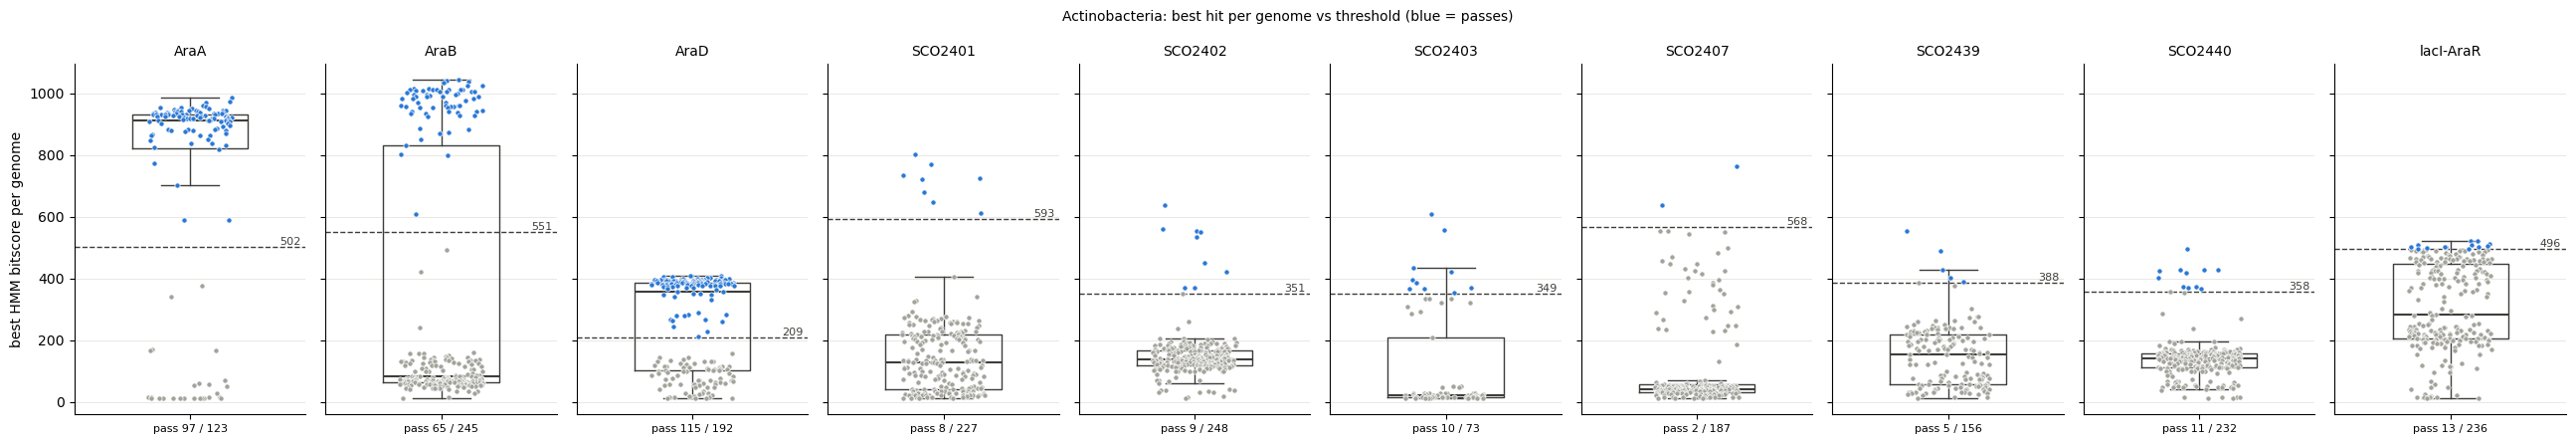

In [17]:
# best hit per (genome, model) in the Actinobacteria set, against the per-model threshold
actino_top = hmm_hits[(hmm_hits.genome_set == "Actinobacteria") & (hmm_hits["rank"] == 1)].copy()
actino_top["threshold"] = actino_top.query_gene.map(thresholds.threshold)
actino_top = actino_top[actino_top.threshold.notna()]  # SCO2408 has no threshold
actino_top["passes"] = actino_top.bitscore >= actino_top.threshold

# every hit per (genome, model) against the threshold, not only the best one: a genome can have several
# passing copies of a gene (e.g. the SCO2403 next to SCO2401 in S. erythraea is its second-best SCO2403 hit)
actino_hits = hmm_hits[hmm_hits.genome_set == "Actinobacteria"].copy()
actino_hits["threshold"] = actino_hits.query_gene.map(thresholds.threshold)
actino_hits = actino_hits[actino_hits.threshold.notna()]
actino_hits["passes"] = actino_hits.bitscore >= actino_hits.threshold

C_PASS = "#2a78d6"
C_FAIL = "#a3a29b"

models = sorted(thresholds.index, key=lambda m: m[-7:])  # by gene, not by the "-" / "_" in the name
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.6 * len(models), 4.5), sharey=True)

for ax, model in zip(axes, models):
    sub = actino_top[actino_top.query_gene == model]
    ax.boxplot(sub.bitscore, positions=[0], widths=0.5, showfliers=False,
               medianprops={"color": "#3d3d3a", "linewidth": 1.5},
               boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
    for passes, color in [(False, C_FAIL), (True, C_PASS)]:
        y = sub.loc[sub.passes == passes, "bitscore"]
        ax.scatter(rng.uniform(-0.18, 0.18, len(y)), y, s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(0.48, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_xticks([0], [f"pass {sub.passes.sum()} / {len(sub)}"], fontsize=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("best HMM bitscore per genome")
fig.suptitle("Actinobacteria: best hit per genome vs threshold (blue = passes)", fontsize=10)
fig.tight_layout()
plt.show()

## Check syntheny araABD

In [18]:
actino_top

,target,target_acc,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,exp,...,description,genome_set,tblout,genome,target_locus_tag,query_gene,rank,is_rbh,threshold,passes
26081,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,-,0.0000,1043.9,8.7,0.0000,1043.8,8.7,1.0,...,-,Actinobacteria,Georgenia_faecalis,Georgenia_faecalis,EBO36_RS13000,AraB,1,False,550.65,True
27020,Jiangella_alkaliphila|BLV05_RS04560|ribulokina...,-,-,0.0000,1042.6,13.8,0.0000,1042.5,13.8,1.0,...,-,Actinobacteria,Jiangella_alkaliphila,Jiangella_alkaliphila,BLV05_RS04560,AraB,1,False,550.65,True
25940,Geodermatophilaceae_bacterium_NBWT11|F1C76_112...,-,-,0.0000,1040.1,7.3,0.0000,1039.9,7.3,1.0,...,-,Actinobacteria,Geodermatophilaceae_bacterium_NBWT11,Geodermatophilaceae_bacterium_NBWT11,F1C76_11215,AraB,1,False,550.65,True
21725,Actinokineospora_sp._UTMC_2448|Actkin_RS14370|...,-,-,0.0000,1033.8,9.5,0.0000,1033.6,9.5,1.0,...,-,Actinobacteria,Actinokineospora_sp._UTMC_2448,Actinokineospora_sp._UTMC_2448,Actkin_RS14370,AraB,1,False,550.65,True
24887,Crossiella_sp._CA-258035|N8J89_RS16055|ribulok...,-,-,0.0000,1025.2,7.7,0.0000,1025.1,7.7,1.0,...,-,Actinobacteria,Crossiella_sp._CA-258035,Crossiella_sp._CA-258035,N8J89_RS16055,AraB,1,False,550.65,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34110,Tropheryma_whipplei_str._Twist|TWT_RS05030|hyp...,-,-,0.0058,11.0,0.1,0.0064,10.8,0.1,1.0,...,protein|WP_038106154.1,Actinobacteria,Tropheryma_whipplei_str._Twist,Tropheryma_whipplei_str._Twist,TWT_RS05030,AraA,1,False,502.00,False
26856,Ilumatobacter_coccineus_YM16-304|YM304_RS21990...,-,-,0.0380,10.9,0.1,2.2000,5.1,0.1,2.5,...,epimerase family protein|WP_015440491.1,Actinobacteria,Ilumatobacter_coccineus_YM16-304,Ilumatobacter_coccineus_YM16-304,YM304_RS21990,SCO2407,1,False,567.55,False
22877,Allosaccharopolyspora_coralli|GIY23_RS20560|GNAT,-,-,0.0320,10.9,0.1,0.0390,10.6,0.1,1.1,...,family N-acetyltransferase|WP_154078163.1,Actinobacteria,Allosaccharopolyspora_coralli,Allosaccharopolyspora_coralli,GIY23_RS20560,AraA,1,False,502.00,False
32730,Salinispora_tropica_CNB-440|STROP_RS07820|pyri...,-,-,0.0370,10.7,0.1,0.0470,10.4,0.1,1.1,...,reductase family protein|WP_011905453.1,Actinobacteria,Salinispora_tropica_CNB-440,Salinispora_tropica_CNB-440,STROP_RS07820,AraA,1,False,502.00,False


In [19]:
# gene order of every passing hit: its position in the genome's .faa file (proteins are in genome order),
# then, for each hit of a trio gene, which of the other two trio genes sit next to it
sys.path.insert(0, str(PROJECT_DIR / "shared"))
from synteny import get_gene_iterator, find_neighbours

ACTINO_FAA_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/faa")
TRIO_WINDOW = 1

actino_passes = actino_hits[actino_hits.passes]


def make_trio_table(top_passes, trio, faa_dir, window=TRIO_WINDOW):
    """One row per passing hit of a trio gene, with the other trio genes within `window` genes of it.

    top_passes: passing hits (a genome can have several per model)
    trio: the three model names, e.g. ["AraA", "AraB", "AraD"]
    faa_dir: folder with the .faa file of every genome, named after its tblout
    """
    rows = []
    # filter for trio genes
    trio_passes = top_passes[top_passes.query_gene.isin(trio)]

    for genome, genome_hits in trio_passes.groupby("genome"):
        # {locus_tag: position} for every protein of this genome; tblout = name of the .faa file it was searched with
        gene_positions = get_gene_iterator(faa_dir / f"{genome_hits.tblout.iloc[0]}.faa")
        # dict {hit_id:model_name} for every passing hit of this genome
        hit_genes_pairs = dict(zip(genome_hits.target_locus_tag, genome_hits.query_gene))

        for hit in genome_hits.itertuples():
            # for every hit find the neighbouring genes within the window
            neighbours = find_neighbours(hit.target_locus_tag, gene_positions, window)
            # write the neighbours like hit_gene:position, hit_gene2:position2, ...
            trio_neighbours = [f"{hit_genes_pairs[neighbour]}:{gene_positions[neighbour]}"
                               for neighbour in neighbours
                               if neighbour in hit_genes_pairs and hit_genes_pairs[neighbour] != hit.query_gene]
            rows.append({
                "genome": genome,
                "model": hit.query_gene,
                "locus_tag": hit.target_locus_tag,
                "position": gene_positions[hit.target_locus_tag],
                "trio_neighbours": ", ".join(trio_neighbours),
                "has_any_trio_neighbour": "yes" if trio_neighbours else "no",
            })

    return pd.DataFrame(rows).sort_values(["genome", "position"]).reset_index(drop=True)


def summarise_trio(trio_table):
    """One row per genome: its trio hits and how many of them have another trio gene as neighbour."""
    return trio_table.groupby("genome").agg(
        n_hits=("model", "size"),
        genes=("model", ", ".join),
        locus_tags=("locus_tag", ", ".join),
        positions=("position", list),
        with_trio_neighbour=("has_any_trio_neighbour", lambda s: (s == "yes").sum()),
    )


# all searched Actinobacteria genomes, with or without hits: one .tblout file per genome
N_ACTINO_GENOMES = len(list(RAW_DIRS["Actinobacteria"].glob("*.tblout")))


def report_trio(trio_summary, label, n_genomes=N_ACTINO_GENOMES):
    """Print how many genomes have all three trio genes next to each other (all 3 hits have a trio neighbour),
    out of all n_genomes searched genomes."""
    clustered = trio_summary[trio_summary.with_trio_neighbour >= 3]
    print(f"{label}: {len(clustered)} of {n_genomes} Actinobacteria genomes ({len(clustered) / n_genomes:.1%}) "
          f"have all three genes next to each other; {len(trio_summary)} genomes have a passing hit "
          f"for at least one {label} gene")
    return clustered


### araBAD (AraA, AraB, AraD)

In [20]:
# araBAD trio
araBAD_table = make_trio_table(actino_passes, ["AraA", "AraB", "AraD"], ACTINO_FAA_DIR)
araBAD_summary = summarise_trio(araBAD_table)
araBAD_clustered = report_trio(araBAD_summary, "araBAD")

display(araBAD_table)
display(araBAD_summary)
araBAD_summary.with_trio_neighbour.value_counts()


araBAD: 47 of 252 Actinobacteria genomes (18.7%) have all three genes next to each other; 118 genomes have a passing hit for at least one araBAD gene


,genome,model,locus_tag,position,trio_neighbours,has_any_trio_neighbour
0,Acidipropionibacterium_acidipropionici_ATCC_4875,AraB,PACID_RS05640,1103,,no
1,Acidipropionibacterium_acidipropionici_ATCC_4875,AraA,PACID_RS10365,2019,AraD:2020,yes
2,Acidipropionibacterium_acidipropionici_ATCC_4875,AraD,PACID_RS10370,2020,AraA:2019,yes
3,Acidothermaceae_bacterium_B102,AraA,acdb102_02260,225,,no
4,Acidothermaceae_bacterium_B102,AraD,acdb102_06000,599,,no
...,...,...,...,...,...,...
295,Varibaculum_prostatecancerukia,AraA,KO216_RS05415,1047,AraD:1048,yes
296,Varibaculum_prostatecancerukia,AraD,KO216_RS05420,1048,AraA:1047,yes
297,Winkia_neuii,AraB,CYJ20_RS00140,25,,no
298,Xylanimonas_cellulosilytica_DSM_15894,AraD,XCEL_RS02030,399,AraA:400,yes


,n_hits,genes,locus_tags,positions,with_trio_neighbour
genome,,,,,
Acidipropionibacterium_acidipropionici_ATCC_4875,3,"AraB, AraA, AraD","PACID_RS05640, PACID_RS10365, PACID_RS10370","[1103, 2019, 2020]",2
Acidothermaceae_bacterium_B102,3,"AraA, AraD, AraB","acdb102_02260, acdb102_06000, acdb102_24870","[225, 599, 2486]",0
Acidothermus_cellulolyticus_11B,3,"AraB, AraD, AraA","ACEL_RS04505, ACEL_RS04510, ACEL_RS04515","[857, 858, 859]",3
Actinacidiphila_bryophytorum,6,"AraA, AraD, AraB, AraA, AraD, AraB","NYE86_RS22665, NYE86_RS22670, NYE86_RS22675, N...","[4321, 4322, 4323, 5406, 5407, 5408]",6
Actinobaculum_sp._313,4,"AraD, AraB, AraD, AraB","DDD63_RS05310, DDD63_RS05800, DDD63_RS09705, D...","[1014, 1110, 1848, 1849]",2
...,...,...,...,...,...
Trueperella_pyogenes,2,"AraB, AraD","CQ11_RS08905, CQ11_RS08910","[1738, 1739]",2
Vaginimicrobium_propionicum,2,"AraD, AraA","CZ356_RS07285, CZ356_RS07320","[1399, 1406]",0
Varibaculum_prostatecancerukia,2,"AraA, AraD","KO216_RS05415, KO216_RS05420","[1047, 1048]",2


with_trio_neighbour
2    43
3    43
0    28
4     3
6     1
Name: count, dtype: int64

### SCO2401-SCO2403

In [21]:
# SCO2401-SCO2403 trio
sco_trio_table = make_trio_table(actino_passes, ["SCO2401", "SCO2402", "SCO2403"], ACTINO_FAA_DIR)
sco_trio_summary = summarise_trio(sco_trio_table)
sco_trio_clustered = report_trio(sco_trio_summary, "SCO2401-SCO2403")

display(sco_trio_table)
display(sco_trio_summary)
sco_trio_summary.with_trio_neighbour.value_counts()


SCO2401-SCO2403: 5 of 252 Actinobacteria genomes (2.0%) have all three genes next to each other; 13 genomes have a passing hit for at least one SCO2401-SCO2403 gene


,genome,model,locus_tag,position,trio_neighbours,has_any_trio_neighbour
0,Actinoalloteichus_hoggarensis,SCO2402,AHOG_RS03705,704,SCO2403:705,yes
1,Actinoalloteichus_hoggarensis,SCO2403,AHOG_RS03715,705,SCO2402:704,yes
2,Actinoalloteichus_hoggarensis,SCO2401,AHOG_RS03745,711,,no
3,Actinocatenispora_sera,SCO2403,Asera_RS28690,5599,SCO2401:5600,yes
4,Actinocatenispora_sera,SCO2401,Asera_RS28695,5600,"SCO2403:5599, SCO2402:5601",yes
5,Actinocatenispora_sera,SCO2402,Asera_RS28700,5601,SCO2401:5600,yes
6,Actinopolymorpha_singaporensis,SCO2402,BLU27_RS01930,385,,no
7,Actinopolyspora_erythraea,SCO2403,CDG81_RS04935,966,SCO2401:967,yes
8,Actinopolyspora_erythraea,SCO2401,CDG81_RS04940,967,"SCO2403:966, SCO2402:968",yes
9,Actinopolyspora_erythraea,SCO2402,CDG81_RS04945,968,SCO2401:967,yes


,n_hits,genes,locus_tags,positions,with_trio_neighbour
genome,,,,,
Actinoalloteichus_hoggarensis,3,"SCO2402, SCO2403, SCO2401","AHOG_RS03705, AHOG_RS03715, AHOG_RS03745","[704, 705, 711]",2
Actinocatenispora_sera,3,"SCO2403, SCO2401, SCO2402","Asera_RS28690, Asera_RS28695, Asera_RS28700","[5599, 5600, 5601]",3
Actinopolymorpha_singaporensis,1,SCO2402,BLU27_RS01930,[385],0
Actinopolyspora_erythraea,3,"SCO2403, SCO2401, SCO2402","CDG81_RS04935, CDG81_RS04940, CDG81_RS04945","[966, 967, 968]",3
Kineococcus_radiotolerans_SRS30216_=_ATCC_BAA-149,1,SCO2402,KRAD_RS08565,[1710],0
Natronosporangium_hydrolyticum,2,"SCO2401, SCO2403","JQS43_RS13650, JQS43_RS13655","[2666, 2667]",2
Pseudonocardia_autotrophica,1,SCO2402,Pdca_RS06600,[1293],0
Rubrobacter_xylanophilus_DSM_9941,2,"SCO2401, SCO2403","RXYL_RS02780, RXYL_RS02785","[554, 555]",2
Saccharopolyspora_erythraea_NRRL_2338,4,"SCO2403, SCO2402, SCO2401, SCO2403","SACE_RS17130, SACE_RS21060, SACE_RS21065, SACE...","[3401, 4187, 4188, 4189]",3


with_trio_neighbour
3    5
0    5
2    3
Name: count, dtype: int64

## Saving for downstream process

In [22]:
# all passing hits (not only the best hit per genome and model)
actino_passed = actino_hits[actino_hits.passes]
actino_passed.to_csv(HMM_DIR / "results" / "actino_top_hits_passed.tsv", sep="\t", index=False)

In [23]:
# Export the Streptomycetae hits for downstream analysis, against the same per-model thresholds as the
# Actinobacteria set: every passing hit, plus the best hit of each (genome, model) even when it fails, so every
# searched genome is in the table. Status is pass or fail.
strep_top = hmm_hits[hmm_hits.genome_set == "Streptomycetae"].copy()
strep_top["threshold"] = strep_top.query_gene.map(thresholds.threshold)
strep_top = strep_top[strep_top.threshold.notna()]
strep_top["passes"] = strep_top.bitscore >= strep_top.threshold
strep_top = strep_top[strep_top.passes | (strep_top["rank"] == 1)]
strep_top["status"] = strep_top.passes.map({True: "pass", False: "fail"})

strep_top.to_csv(HMM_DIR / "results" / "strep_top_hits.tsv", sep="\t", index=False)
print(f"{len(strep_top)} hits from {strep_top.tblout.nunique()} genomes, {strep_top.passes.sum()} pass")

1860 hits from 207 genomes, 903 pass


## Benchmark: RBH vs HMM in the Actinobacteria set

Every best HMM hit per (genome, model), every other passing copy, and every RBH protein that is not the best hit,
labelled by which method finds it (both / HMM only / RBH only / neither).

In [24]:
RBH_ACTINO_HITS = PROJECT_DIR / "RBH" / "results" / "diamond_reverseBLAST_actinos" / "reciprocal" / "reciprocal_hits.tsv"
BENCH_KEYS = ["genome", "query_gene", "target_locus_tag"]

# reciprocal best hits in the Actinobacteria set; rows without rev_bitscore failed the reciprocal check
rbh_actino = pd.read_csv(RBH_ACTINO_HITS, sep="\t")
print(f"{rbh_actino.rev_bitscore.isna().sum()} forward hits failed the reciprocal check (dropped)")
rbh_actino = rbh_actino[rbh_actino.rev_bitscore.notna()].copy()
rbh_actino["query_gene"] = rbh_actino.qseqid.map(RBH_TO_MODEL)
# brackets dropped, as for the HMM genome names ('[Actinomadura]_parvosata_subsp._kistnae')
rbh_actino["genome"] = rbh_actino.sseqid.str.split("|").str[0].str.replace("[", "").str.replace("]", "")
rbh_actino["target_locus_tag"] = rbh_actino.sseqid.str.split("|").str[1]
rbh_actino = rbh_actino[rbh_actino.query_gene.isin(models)]

# the RBH database also holds genomes that were not HMM-searched (e.g. the outgroups added later)
not_searched = sorted(set(rbh_actino.genome) - set(actino_top.genome))
if not_searched:
    print(f"RBH hits in {len(not_searched)} genomes without HMM results (dropped):", ", ".join(not_searched))
rbh_actino = rbh_actino[rbh_actino.genome.isin(actino_top.genome)]
rbh_keys_actino = pd.MultiIndex.from_frame(rbh_actino[BENCH_KEYS])

# best hit of every (genome, model), every other passing copy, and every RBH protein that is not the best hit
# (e.g. a second AraA copy); each one passes when its own bitscore reaches the model threshold
actino_keys = pd.MultiIndex.from_frame(actino_hits[BENCH_KEYS])
bench = (
    actino_hits[(actino_hits["rank"] == 1) | actino_hits.passes | actino_keys.isin(rbh_keys_actino)]
    [BENCH_KEYS + ["target", "tblout", "bitscore", "rank", "passes"]]
    .rename(columns={"passes": "hmm_pass"})
    .reset_index(drop=True)
)
bench["is_rbh"] = pd.MultiIndex.from_frame(bench[BENCH_KEYS]).isin(rbh_keys_actino)
bench["call"] = np.select(
    [bench.hmm_pass & bench.is_rbh, bench.hmm_pass, bench.is_rbh],
    ["both", "HMM only", "RBH only"],
    default="neither",
)

# RBH hits that hmmsearch did not report at all (cannot be placed on the bitscore axis)
rbh_not_in_hmm = rbh_actino[~rbh_keys_actino.isin(actino_keys)]
print(f"{len(rbh_not_in_hmm)} RBH hits not reported by hmmsearch")
if len(rbh_not_in_hmm):
    print(rbh_not_in_hmm.groupby("query_gene").size().to_string())

pd.crosstab(bench.query_gene, bench.call).reindex(index=models, columns=["both", "HMM only", "RBH only", "neither"], fill_value=0)

2 forward hits failed the reciprocal check (dropped)
RBH hits in 1 genomes without HMM results (dropped): Bacillus_subtilis_subsp._subtilis_str._168
0 RBH hits not reported by hmmsearch


call,both,HMM only,RBH only,neither
query_gene,,,,
AraA,96,5,0,26
AraB,65,5,0,180
AraD,5,124,0,77
SCO2401,8,0,0,219
SCO2402,9,0,1,238
SCO2403,9,2,6,57
SCO2407,2,0,18,167
SCO2439,5,0,21,131
SCO2440,11,0,5,216


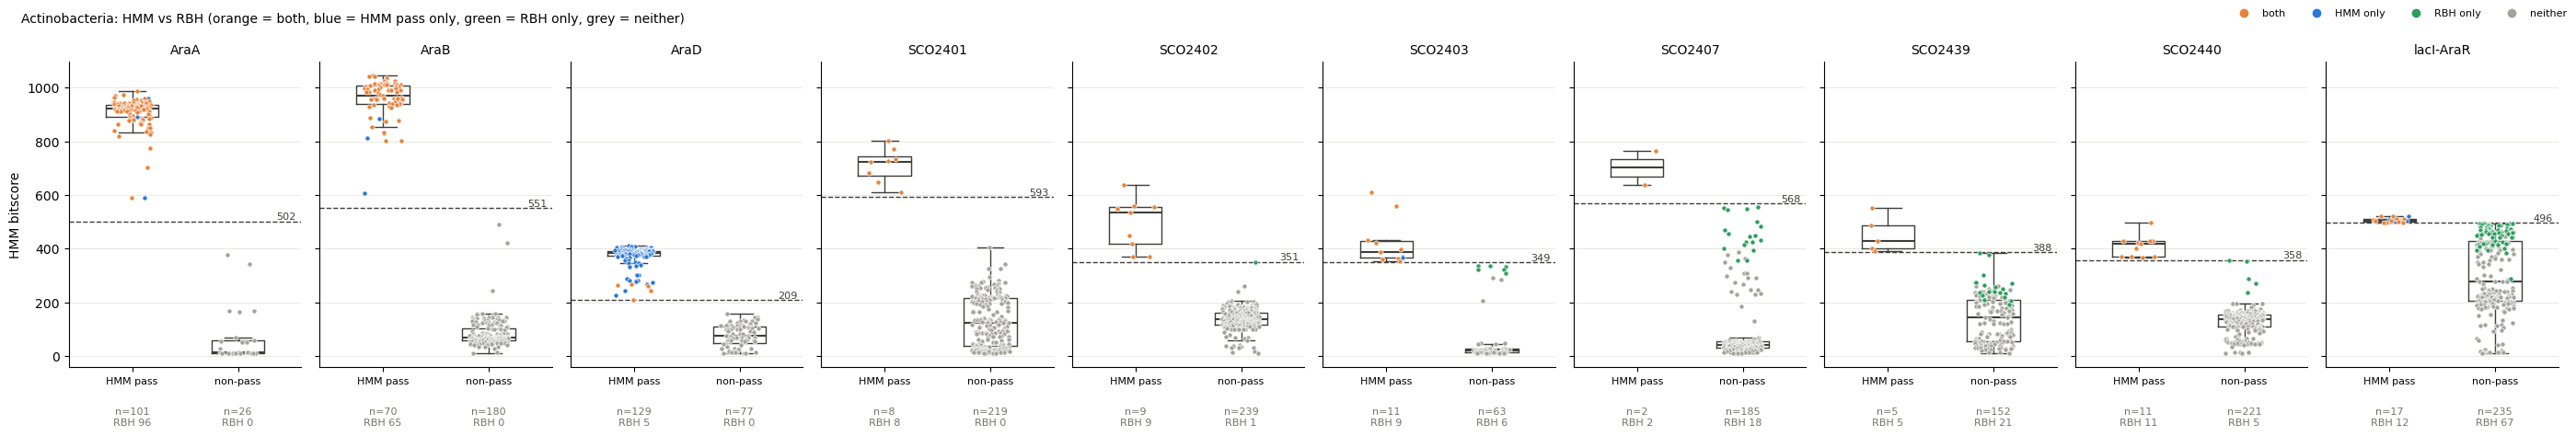

In [25]:
# HMM bitscore of every benchmarked hit, split into HMM pass / non-pass;
# orange = HMM pass and RBH, blue = HMM pass only, green = RBH only, grey = neither
C_BOTH = "#e8833a"
C_HMM_ONLY = C_PASS
C_RBH_ONLY = "#2e9e5b"
CALL_COLORS = [("neither", C_FAIL), ("HMM only", C_HMM_ONLY), ("RBH only", C_RBH_ONLY), ("both", C_BOTH)]  # drawn in this order

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, len(models), figsize=(2.8 * len(models), 4.8), sharey=True)

for ax, model in zip(axes, models):
    sub = bench[bench.query_gene == model]
    for x, (label, in_group) in enumerate([("HMM pass", sub.hmm_pass), ("non-pass", ~sub.hmm_pass)]):
        group = sub[in_group]
        ax.boxplot(group.bitscore, positions=[x], widths=0.5, showfliers=False,
                   medianprops={"color": "#3d3d3a", "linewidth": 1.5},
                   boxprops={"color": "#3d3d3a"}, whiskerprops={"color": "#3d3d3a"}, capprops={"color": "#3d3d3a"})
        jitter = pd.Series(rng.uniform(-0.18, 0.18, len(group)), index=group.index)
        for call, color in CALL_COLORS:
            is_call = group.call == call
            ax.scatter(x + jitter[is_call], group.bitscore[is_call], s=14, color=color,
                       edgecolor="white", linewidth=0.5, zorder=3)
        ax.text(x, -0.13, f"n={len(group)}\nRBH {group.is_rbh.sum()}", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=8, color="#73726c")
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(1.55, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_xticks([0, 1], ["HMM pass", "non-pass"], fontsize=8)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(model, fontsize=10)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("HMM bitscore")
handles = [plt.Line2D([], [], marker="o", linestyle="", color=color, label=call)
           for call, color in [CALL_COLORS[i] for i in (3, 1, 2, 0)]]  # both, HMM only, RBH only, neither
fig.legend(handles=handles, loc="upper right", ncol=4, fontsize=8, frameon=False)
fig.suptitle("Actinobacteria: HMM vs RBH (orange = both, blue = HMM pass only, green = RBH only, grey = neither)",
             fontsize=10, x=0.01, ha="left")
fig.tight_layout()
plt.show()

### Identity to the RBH query vs HMM bitscore

Every benchmarked hit aligned to its RBH query with DIAMOND, without the RBH identity/coverage cutoffs, so hits below
the forward cutoffs also get a value; then checked against the RBH forward cutoffs in `RBH/config/actinos.yaml`.

In [26]:
import subprocess
import yaml

DIAMOND = "/vol/local/calarass/envs/diamond/bin/diamond"
DIAMOND_THREADS = 4
RBH_CONFIG = yaml.safe_load(open(PROJECT_DIR / "RBH" / "config" / "actinos.yaml"))
QUERY_DIR = PROJECT_DIR / "RBH" / "data" / "arabinose_clusters"
IDENT_DIR = HMM_DIR / "results" / "hmm_vs_query_identity"
IDENT_DIR.mkdir(exist_ok=True)
ALN_COLS = ["qseqid", "sseqid", "pident", "length", "qlen", "slen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]


def read_faa(path, wanted):
    """{id: sequence} for the ids in wanted; id = header up to the first space, as HMMER and DIAMOND report it."""
    seqs, header = {}, None
    with open(path) as f:
        for line in f:
            if line.startswith(">"):
                header = line[1:].split()[0]
            elif header in wanted:
                seqs[header] = seqs.get(header, "") + line.strip()
    return seqs


# protein sequence of every benchmarked hit, from the .faa file its genome was searched with
hits_faa = IDENT_DIR / "bench_hits.faa"
with open(hits_faa, "w") as out:
    for tblout, targets in bench.groupby("tblout").target:
        for header, seq in read_faa(ACTINO_FAA_DIR / f"{tblout}.faa", set(targets)).items():
            out.write(f">{header}\n{seq}\n")
queries_faa = IDENT_DIR / "queries.faa"
with open(queries_faa, "w") as out:
    for path in sorted(QUERY_DIR.glob("*.fasta")):
        out.write(open(path).read().rstrip("\n") + "\n")

# every query against every hit, no identity/coverage cutoff
subprocess.run([DIAMOND, "makedb", "--quiet", "--threads", str(DIAMOND_THREADS),
                "--in", str(hits_faa), "-d", str(IDENT_DIR / "bench_hits")], check=True)
subprocess.run([DIAMOND, "blastp", "--quiet", "--threads", str(DIAMOND_THREADS),
                "-q", str(queries_faa), "-d", str(IDENT_DIR / "bench_hits"),
                "--very-sensitive", "--max-target-seqs", "0", "-e", "10", "--tmpdir", str(IDENT_DIR),
                "-o", str(IDENT_DIR / "query_vs_hits.tsv"), "-f", "6", *ALN_COLS], check=True)
aln = pd.read_csv(IDENT_DIR / "query_vs_hits.tsv", sep="\t", names=ALN_COLS)
aln["query_gene"] = aln.qseqid.map(RBH_TO_MODEL)
# keep each hit's alignment to the query of its own model, best HSP only
aln = aln.sort_values("bitscore", ascending=False).drop_duplicates(["query_gene", "sseqid"])
aln["qcov"] = 100 * (aln.qend - aln.qstart + 1) / aln.qlen
aln["scov"] = 100 * (aln.send - aln.sstart + 1) / aln.slen

ident = bench.merge(aln[["query_gene", "sseqid", "pident", "qcov", "scov"]].rename(columns={"sseqid": "target"}),
                    on=["query_gene", "target"], how="left")
# would the hit pass the RBH forward cutoffs (identity / query cover / subject cover); no alignment -> fails
ident["passes_fwd_id"] = ident.pident >= RBH_CONFIG["fwd_id"]
ident["passes_fwd_cov"] = (ident.qcov >= RBH_CONFIG["fwd_qcov"]) & (ident.scov >= RBH_CONFIG["fwd_scov"])
ident["passes_fwd"] = ident.passes_fwd_id & ident.passes_fwd_cov

print(f"RBH forward cutoffs: identity >= {RBH_CONFIG['fwd_id']}%, "
      f"query cover >= {RBH_CONFIG['fwd_qcov']}%, subject cover >= {RBH_CONFIG['fwd_scov']}%")
print(f"{ident.pident.isna().sum()} of {len(ident)} hits do not align to their query at all (E <= 10), not plotted")
ident.groupby(["query_gene", "call"]).agg(
    hits=("target", "size"),
    pident_min=("pident", "min"), pident_median=("pident", "median"), pident_max=("pident", "max"),
    pass_identity=("passes_fwd_id", "sum"), pass_coverage=("passes_fwd_cov", "sum"), pass_both=("passes_fwd", "sum"),
).reindex(models, level=0).round(1)

RBH forward cutoffs: identity >= 45%, query cover >= 65%, subject cover >= 65%
233 of 1960 hits do not align to their query at all (E <= 10), not plotted


hits  pident_min  pident_median  pident_max  \
query_gene call                                                    
AraA       HMM only     5        44.2           69.4        78.2   
           both        96        45.7           69.0        81.5   
           neither     26        23.4           29.2        69.8   
AraB       HMM only     5        45.0           50.9        68.7   
           both        65        48.9           65.9        81.9   
           neither    180        21.0           27.9        42.7   
AraD       HMM only   124        34.2           37.8        41.6   
           both         5        47.4           54.1        70.4   
           neither     77        23.2           30.4        55.6   
SCO2401    both         8        52.2           66.4        99.7   
           neither    219        20.9           29.7        56.5   
SCO2402    RBH only     1        45.5           45.5        45.5   
           both         9        48.4           56.1       100.0   
           neither    238        25.3           30.9        40.7   
SCO2403    HMM only     2        43.1           44.4        45.8   
           RBH only     6        45.0           48.5        53.8   
           both         9        45.8           53.3        99.7   
           neither     57        26.5           37.4        43.1   
SCO2407    RBH only    18        45.7           49.5        58.8   
           both         2        57.4           78.7       100.0   
           neither    167        21.4           27.0        45.1   
SCO2439    RBH only    21        45.2           47.0        58.1   
           both         5        59.5           64.7       100.0   
           neither    131        23.6           36.6        48.4   
SCO2440    RBH only     5        46.1           49.2        55.5   
           both        11        57.2           61.3       100.0   
           neither    216        23.2           33.1        39.4   
lacI-AraR  HMM only     5        53.8           58.3        67.1   
           RBH only    67        45.1           48.3        62.0   
           both        12        45.4           59.6        70.6   
           neither    168        25.6           33.7        54.2   

                     pass_identity  pass_coverage  pass_both  
query_gene call                                               
AraA       HMM only              4              5          4  
           both                 96             96         96  
           neither               2              6          0  
AraB       HMM only              5              5          5  
           both                 65             65         65  
           neither               0            101          0  
AraD       HMM only              0            122          0  
           both                  5              5          5  
           neither               1             26          0  
SCO2401    both                  8              8          8  
           neither               1            155          0  
SCO2402    RBH only              1              1          1  
           both                  9              9          9  
           neither               0            223          0  
SCO2403    HMM only              1              2          1  
           RBH only              6              6          6  
           both                  9              9          9  
           neither               0              3          0  
SCO2407    RBH only             18             18         18  
           both                  2              2          2  
           neither               1             52          1  
SCO2439    RBH only             21             21         21  
           both                  5              5          5  
           neither               2             95          1  
SCO2440    RBH only              5              5          5  
           both                 11             11         11  
           n

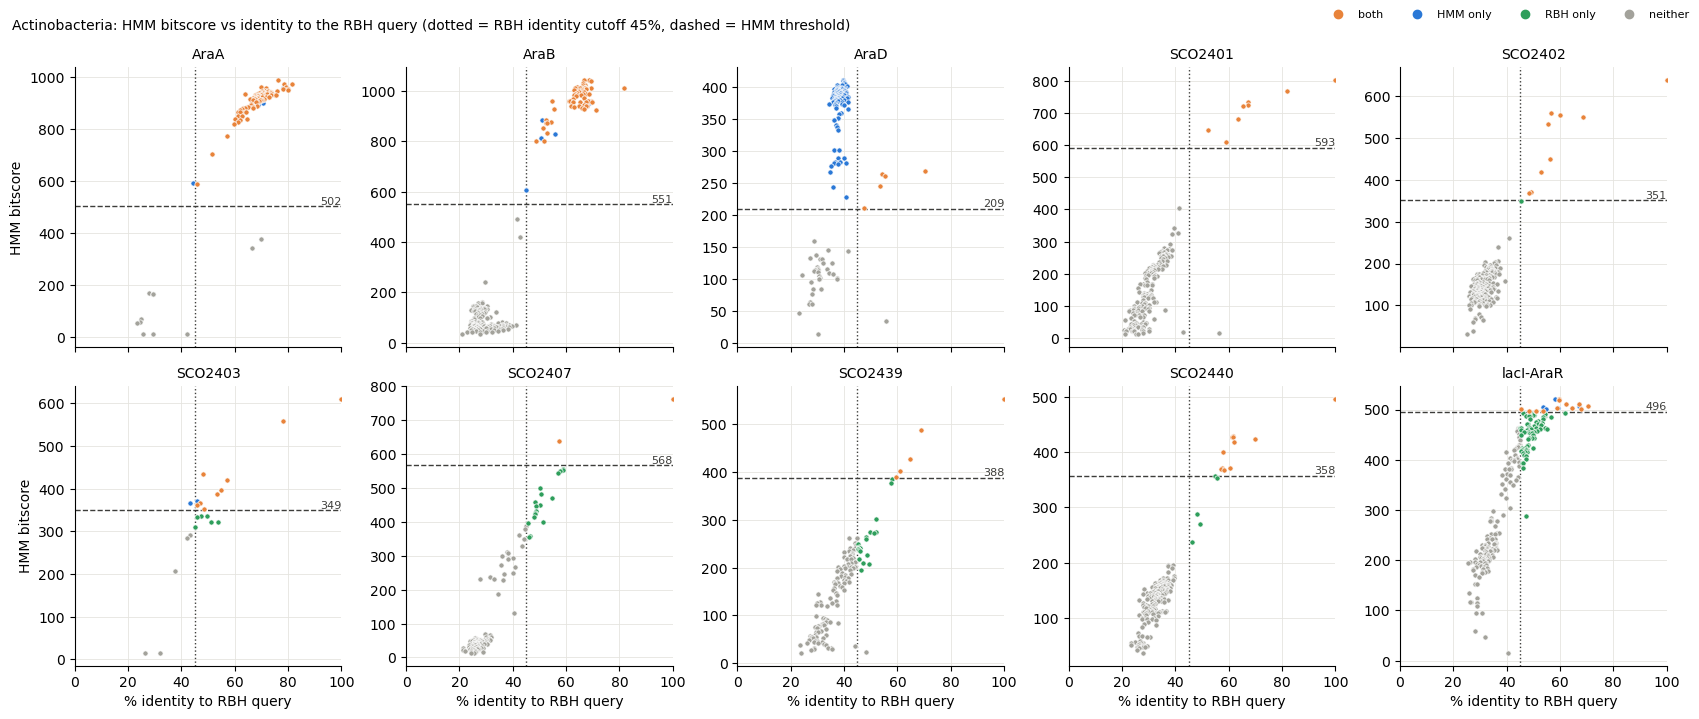

In [27]:
# % identity to the RBH query vs HMM bitscore, one panel per model, coloured as in the benchmark plot;
# dotted = RBH forward identity cutoff, dashed = HMM threshold
n_cols = 5
fig, axes = plt.subplots(int(np.ceil(len(models) / n_cols)), n_cols, figsize=(3.4 * n_cols, 7.2), sharex=True)

for ax, model in zip(axes.flat, models):
    sub = ident[(ident.query_gene == model) & ident.pident.notna()]
    for call, color in CALL_COLORS:
        is_call = sub.call == call
        ax.scatter(sub.pident[is_call], sub.bitscore[is_call], s=14, color=color,
                   edgecolor="white", linewidth=0.5, zorder=3)
    ax.axvline(RBH_CONFIG["fwd_id"], color="#3d3d3a", linestyle=":", linewidth=1)
    threshold = thresholds.loc[model, "threshold"]
    ax.axhline(threshold, color="#3d3d3a", linestyle="--", linewidth=1)
    ax.text(100, threshold, f"{threshold:.0f}", fontsize=8, va="bottom", ha="right", color="#3d3d3a")
    ax.set_title(model, fontsize=10)
    ax.set_xlim(0, 100)
    ax.grid(color="#e5e4df", linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
for ax in axes.flat[len(models):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("HMM bitscore")
for ax in axes[-1, :]:
    ax.set_xlabel("% identity to RBH query")

handles = [plt.Line2D([], [], marker="o", linestyle="", color=color, label=call)
           for call, color in [CALL_COLORS[i] for i in (3, 1, 2, 0)]]  # both, HMM only, RBH only, neither
fig.legend(handles=handles, loc="upper right", ncol=4, fontsize=8, frameon=False)
fig.suptitle(f"Actinobacteria: HMM bitscore vs identity to the RBH query "
             f"(dotted = RBH identity cutoff {RBH_CONFIG['fwd_id']}%, dashed = HMM threshold)",
             fontsize=10, x=0.01, ha="left")
fig.tight_layout()
plt.show()

## Alignment table: every HMM hit with its HMMER and BLAST alignment

One row per hmmsearch hit (both genome sets). HMMER: model and target coverage of the included domains and the
identity of the aligned target residues to the model consensus, parsed from the hmmsearch text output in `logs/`
(the .tblout files have scores only). BLAST: DIAMOND alignment of the hit to the RBH query of its model, no cutoffs.
Saved to `results/hmm_hits_alignment_stats.tsv`.

In [28]:
BLAST_ALL = HMM_DIR / "results" / "hmm_hits_alignment" / "query_vs_all_hits.tsv"
BLAST_COLS = ["qseqid", "sseqid", "pident", "length", "qlen", "slen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

blast = pd.read_csv(BLAST_ALL, sep="\t", names=BLAST_COLS)
# query name -> HMM model name, so each hit is matched to the query of its own model
blast["query_gene"] = blast.qseqid.map(RBH_TO_MODEL)
# best HSP per (query gene, hit)
blast = blast.sort_values("bitscore", ascending=False).drop_duplicates(["query_gene", "sseqid"])
# % of the query and of the hit covered by the alignment
blast["qcov"] = 100 * (blast.qend - blast.qstart + 1) / blast.qlen
blast["scov"] = 100 * (blast.send - blast.sstart + 1) / blast.slen
blast = blast.rename(columns={"sseqid": "target"}).add_prefix("blast_").rename(
    columns={"blast_target": "target", "blast_query_gene": "query_gene"})

# every HMMER hit, with its BLAST alignment to its own query (empty when DIAMOND found none)
hmm_blast = hmm_hits.merge(blast, on=["query_gene", "target"], how="left")
print(f"{len(hmm_blast)} HMMER hits, {hmm_blast.blast_pident.notna().sum()} with a BLAST alignment to their query")
hmm_blast

# pass / fail of every Actinobacteria hit against its model threshold (Streptomycetae hits stay empty)
hmm_blast = hmm_blast.merge(
    actino_hits[["genome_set", "query_gene", "target", "threshold", "passes"]],
    on=["genome_set", "query_gene", "target"], how="left",
)
hmm_blast

34407 HMMER hits, 27888 with a BLAST alignment to their query


,target,target_acc,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,exp,...,blast_qstart,blast_qend,blast_sstart,blast_send,blast_evalue,blast_bitscore,blast_qcov,blast_scov,threshold,passes
0,Streptomyces_venezuelae|vnz_RS33510|ribulokina...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1.0,568.0,1.0,568.0,0.000000e+00,1148.0,100.000000,100.000000,NaN,NaN
1,Streptomyces_venezuelae_ATCC_10712|DEJ43_RS336...,-,-,0.00,1053.2,4.7,0.000,1052.9,4.7,1.0,...,1.0,568.0,1.0,568.0,0.000000e+00,1148.0,100.000000,100.000000,NaN,NaN
2,Georgenia_faecalis|EBO36_RS13000|ribulokinase|...,-,-,0.00,1043.9,8.7,0.000,1043.8,8.7,1.0,...,17.0,562.0,7.0,553.0,5.420000e-268,743.0,96.126761,94.800693,550.65,True
3,Streptomyces_tanashiensis|LDH80_RS06025|ribulo...,-,-,0.00,1043.2,5.2,0.000,1042.9,5.2,1.0,...,1.0,568.0,1.0,568.0,0.000000e+00,1110.0,100.000000,100.000000,NaN,NaN
4,Streptomyces_gardneri|H4W23_RS03215|ribulokina...,-,-,0.00,1042.9,5.6,0.000,1042.6,5.6,1.0,...,1.0,568.0,1.0,568.0,0.000000e+00,1083.0,100.000000,100.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34402,Streptomyces_stoeckheimensis|ACE1OC_RS37635|xy...,-,-,1.60,5.9,11.1,0.150,9.3,0.2,3.1,...,20.0,495.0,8.0,421.0,1.090000e-04,44.7,83.802817,86.974790,NaN,NaN
34403,Mycobacterium_tuberculosis_H37Rv|Rv2181|alpha-...,-,-,1.20,5.9,6.3,1.900,5.3,0.6,2.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,351.45,False
34404,Paeniglutamicibacter_sp._Y32M11|KUF55_RS08720|...,-,-,0.74,5.8,6.8,0.068,9.3,1.6,1.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,550.65,False
34405,Streptomyces_clavuligerus|CRV15_RS31785|hypoth...,-,-,3.30,5.3,7.4,3.800,5.0,6.9,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Check araD 
# AraD hits that pass the HMM threshold but are below the 45% RBH identity cutoff
araD_low_id = (
    hmm_blast[(hmm_blast.query_gene == "AraD") & (hmm_blast.passes == True) & (hmm_blast.blast_pident < 45)]
    [["genome", "target_locus_tag", "rank",
      "evalue", "bitscore", "threshold", "best_dom_evalue", "best_dom_bitscore",
      "blast_pident", "blast_evalue", "blast_bitscore", "blast_length", "blast_qcov", "blast_scov"]]
    .sort_values("bitscore", ascending=False)
    .reset_index(drop=True)
)
print(f"{len(araD_low_id)} AraD hits pass the HMM threshold with < 45% identity to vnz araD")
araD_low_id.round(1)


124 AraD hits pass the HMM threshold with < 45% identity to vnz araD


,genome,target_locus_tag,rank,evalue,bitscore,threshold,best_dom_evalue,best_dom_bitscore,blast_pident,blast_evalue,blast_bitscore,blast_length,blast_qcov,blast_scov
0,Jiangella_alkaliphila,BLV05_RS04565,1,0.0,410.2,209.4,0.0,410.1,39.6,0.0,127.0,217.0,91.1,94.5
1,Microlunatus_phosphovorus_NM-1,MLP_RS07370,1,0.0,408.7,209.4,0.0,408.5,39.5,0.0,114.0,190.0,80.2,77.4
2,Actinomadura_parvosata_subsp._kistnae,BKM31_RS58065,1,0.0,407.6,209.4,0.0,407.5,40.1,0.0,123.0,217.0,91.1,94.0
3,Sanguibacter_keddieii_DSM_10542,SKED_RS03390,1,0.0,405.9,209.4,0.0,405.6,39.9,0.0,121.0,218.0,90.7,87.2
4,Couchioplanes_caeruleus,COUCH_RS18910,1,0.0,405.3,209.4,0.0,405.2,39.9,0.0,127.0,198.0,83.5,83.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Dermatophilus_congolensis,CKV89_RS12275,1,0.0,278.5,209.4,0.0,277.7,37.6,0.0,128.0,226.0,93.7,40.2
120,Actinotignum_schaalii,FB03_RS07060,2,0.0,276.3,209.4,0.0,276.1,35.2,0.0,119.0,216.0,90.3,91.0
121,Arachnia_propionica_F0230a,HMPREF9154_RS05555,1,0.0,266.3,209.4,0.0,266.0,34.7,0.0,112.0,225.0,92.8,94.6
122,Protaetiibacter_intestinalis,D7I47_RS03170,2,0.0,243.5,209.4,0.0,243.2,35.9,0.0,92.8,209.0,86.5,69.1


In [30]:
# synteny of each low-identity AraD hit: which passing AraA / AraB sit directly next to it (araBAD_table, window 1)
araD_low_id = araD_low_id.merge(
    araBAD_table[["genome", "locus_tag", "trio_neighbours", "has_any_trio_neighbour"]]
    .rename(columns={"locus_tag": "target_locus_tag"}),
    on=["genome", "target_locus_tag"], how="left",
)
print(araD_low_id.has_any_trio_neighbour.value_counts().to_string())
araD_low_id

has_any_trio_neighbour
yes    94
no     30


,genome,target_locus_tag,rank,evalue,bitscore,threshold,best_dom_evalue,best_dom_bitscore,blast_pident,blast_evalue,blast_bitscore,blast_length,blast_qcov,blast_scov,trio_neighbours,has_any_trio_neighbour
0,Jiangella_alkaliphila,BLV05_RS04565,1,7.500000e-124,410.2,209.4,8.300000e-124,410.1,39.6,3.360000e-36,127.0,217.0,91.139241,94.470046,"AraB:907, AraA:909",yes
1,Microlunatus_phosphovorus_NM-1,MLP_RS07370,1,1.600000e-123,408.7,209.4,1.900000e-123,408.5,39.5,3.680000e-31,114.0,190.0,80.168776,77.391304,AraA:1456,yes
2,Actinomadura_parvosata_subsp._kistnae,BKM31_RS58065,1,8.000000e-123,407.6,209.4,8.800000e-123,407.5,40.1,1.060000e-34,123.0,217.0,91.139241,94.036697,"AraB:11593, AraA:11595",yes
3,Sanguibacter_keddieii_DSM_10542,SKED_RS03390,1,8.500000e-123,405.9,209.4,1.000000e-122,405.6,39.9,8.810000e-34,121.0,218.0,90.717300,87.179487,"AraB:664, AraA:666",yes
4,Couchioplanes_caeruleus,COUCH_RS18910,1,2.600000e-122,405.3,209.4,2.800000e-122,405.2,39.9,3.930000e-36,127.0,198.0,83.544304,83.408072,AraA:3717,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Dermatophilus_congolensis,CKV89_RS12275,1,4.600000e-84,278.5,209.4,7.700000e-84,277.7,37.6,2.050000e-34,128.0,226.0,93.670886,40.151515,,no
120,Actinotignum_schaalii,FB03_RS07060,2,1.600000e-83,276.3,209.4,1.900000e-83,276.1,35.2,3.600000e-33,119.0,216.0,90.295359,90.990991,,no
121,Arachnia_propionica_F0230a,HMPREF9154_RS05555,1,3.300000e-80,266.3,209.4,3.900000e-80,266.0,34.7,1.180000e-30,112.0,225.0,92.827004,94.594595,,no
122,Protaetiibacter_intestinalis,D7I47_RS03170,2,2.900000e-73,243.5,209.4,3.500000e-73,243.2,35.9,1.440000e-22,92.8,209.0,86.497890,69.064748,,no


In [31]:
araD_low_id.head(50)

,genome,target_locus_tag,rank,evalue,bitscore,threshold,best_dom_evalue,best_dom_bitscore,blast_pident,blast_evalue,blast_bitscore,blast_length,blast_qcov,blast_scov,trio_neighbours,has_any_trio_neighbour
0,Jiangella_alkaliphila,BLV05_RS04565,1,7.500000e-124,410.2,209.4,8.300000e-124,410.1,39.6,3.360000e-36,127.0,217.0,91.139241,94.470046,"AraB:907, AraA:909",yes
1,Microlunatus_phosphovorus_NM-1,MLP_RS07370,1,1.600000e-123,408.7,209.4,1.900000e-123,408.5,39.5,3.680000e-31,114.0,190.0,80.168776,77.391304,AraA:1456,yes
2,Actinomadura_parvosata_subsp._kistnae,BKM31_RS58065,1,8.000000e-123,407.6,209.4,8.800000e-123,407.5,40.1,1.060000e-34,123.0,217.0,91.139241,94.036697,"AraB:11593, AraA:11595",yes
3,Sanguibacter_keddieii_DSM_10542,SKED_RS03390,1,8.500000e-123,405.9,209.4,1.000000e-122,405.6,39.9,8.810000e-34,121.0,218.0,90.717300,87.179487,"AraB:664, AraA:666",yes
4,Couchioplanes_caeruleus,COUCH_RS18910,1,2.600000e-122,405.3,209.4,2.800000e-122,405.2,39.9,3.930000e-36,127.0,198.0,83.544304,83.408072,AraA:3717,yes
5,Raineyella_fluvialis,Rai3103_RS12115,1,4.400000e-122,403.3,209.4,5.200000e-122,403.1,40.3,7.750000e-36,126.0,221.0,92.827004,88.559322,,no
6,Pengzhenrongella_sicca,J4E96_RS18155,1,7.400000e-122,402.9,209.4,9.300000e-122,402.6,39.1,9.030000e-34,121.0,215.0,90.295359,86.382979,AraA:3546,yes
7,Aeromicrobium_erythreum,Aeryth_RS15265,1,6.500000e-122,402.9,209.4,7.200000e-122,402.7,37.4,4.480000e-31,114.0,222.0,93.248945,93.750000,"AraA:3031, AraB:3033",yes
8,Miniimonas_sp._S16,DCS86_RS05565,1,3.300000e-121,400.5,209.4,3.600000e-121,400.4,41.2,3.910000e-36,127.0,211.0,85.654008,84.322034,AraA:1060,yes
9,Nocardioides_sp._JS614,NOCA_RS03335,1,1.000000e-120,399.5,209.4,1.200000e-120,399.3,37.5,6.260000e-31,114.0,216.0,89.451477,85.714286,"AraB:386, AraA:388",yes
